In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

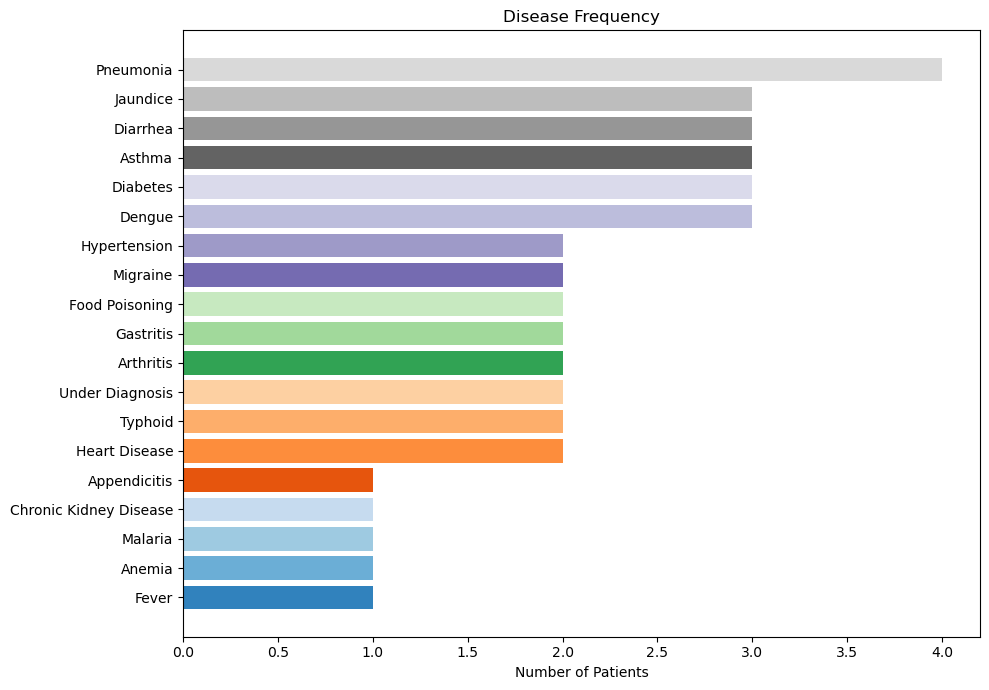

In [7]:
# Plot disease frequency
df = pd.read_csv('hospital_patient_cleaned_dataset.csv')

disease_counts = df['Disease'].value_counts().sort_values()
colors_bar = plt.cm.tab20c(np.linspace(0, 1, len(disease_counts)))

plt.figure(figsize=(10, 7))
plt.barh(disease_counts.index, disease_counts.values, color=colors_bar,)

plt.xlabel('Number of Patients')
plt.title('Disease Frequency')
plt.tight_layout()
# plt.savefig('plot_disease_frequency.png', dpi=150)
plt.show()

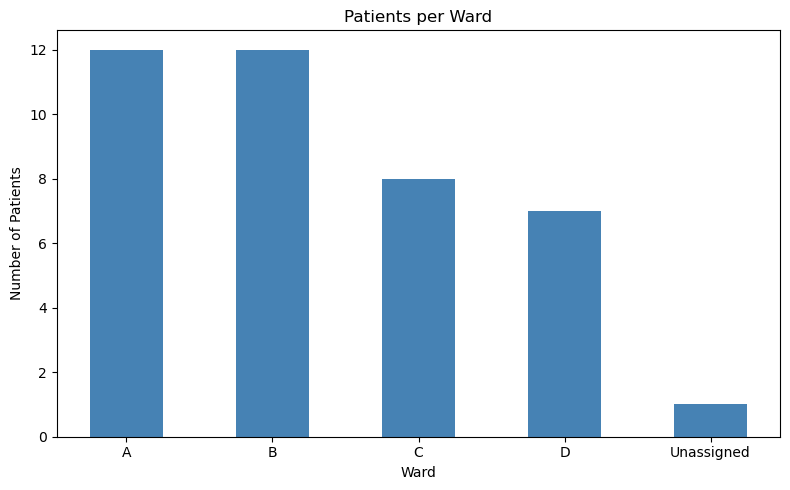

In [8]:
df = pd.read_csv('hospital_patient_cleaned_dataset.csv')

ward_counts = df['Ward'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ward_counts.index, ward_counts.values, color='steelblue', width=0.5)

plt.xlabel('Ward')
plt.ylabel('Number of Patients')
plt.title('Patients per Ward')
plt.tight_layout()
plt.savefig('plot_patients_per_ward.png', dpi=150)
plt.show()

#Pie Chart: Gender Distribution

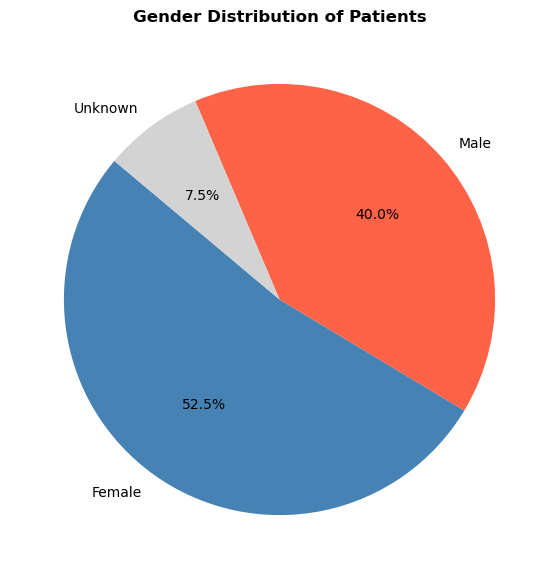

Plot 5 saved: plot5_gender_pie.png


In [9]:
gender_counts = df['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato', 'lightgray'][:len(gender_counts)],
    startangle=140
)

ax.set_title('Gender Distribution of Patients', fontweight='bold')
# plt.savefig('plot5_gender_pie.png', dpi=150)
plt.show()
print('Plot 5 saved: plot5_gender_pie.png')

#Ward Vs Disease:bar plot


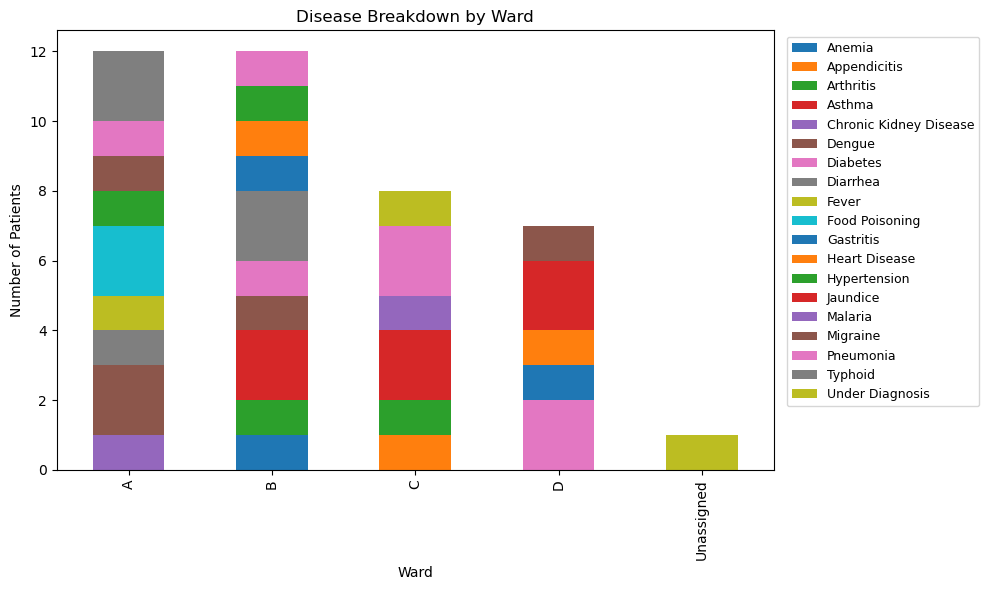

In [10]:
df = pd.read_csv('hospital_patient_cleaned_dataset.csv')

ward_disease = df.groupby(['Ward', 'Disease']).size().unstack(fill_value=0)

ward_disease.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Disease Breakdown by Ward')
plt.xlabel('Ward')
plt.ylabel('Number of Patients')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('plot_ward_disease.png', dpi=150)
plt.show()

#Admission Trend using Line chart

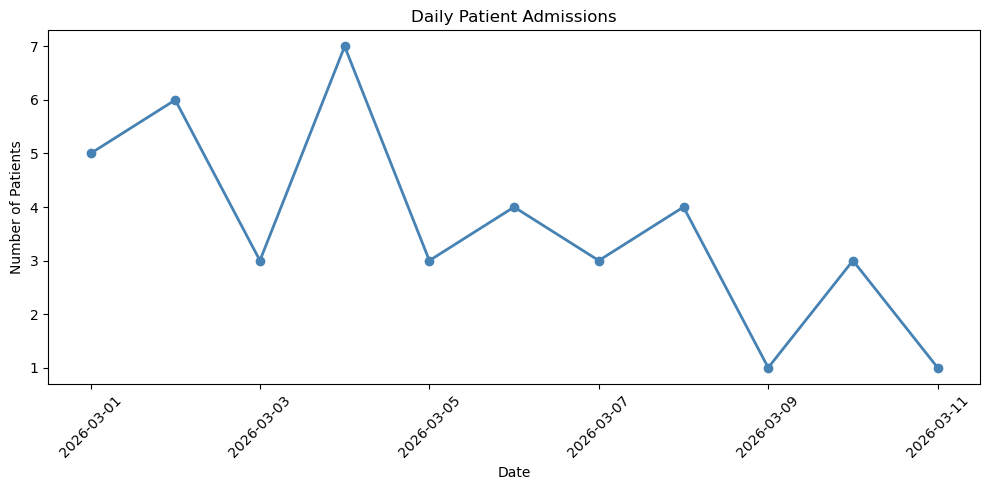

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hospital_patient_cleaned_dataset.csv')

df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'], errors='coerce')
admit_counts = df.groupby('AdmissionDate').size()

plt.figure(figsize=(10, 5))
plt.plot(admit_counts.index, admit_counts.values,
         marker='o', color='steelblue', linewidth=2)

plt.title('Daily Patient Admissions')
plt.xlabel('Date')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_admission_trend.png', dpi=150)
plt.show()

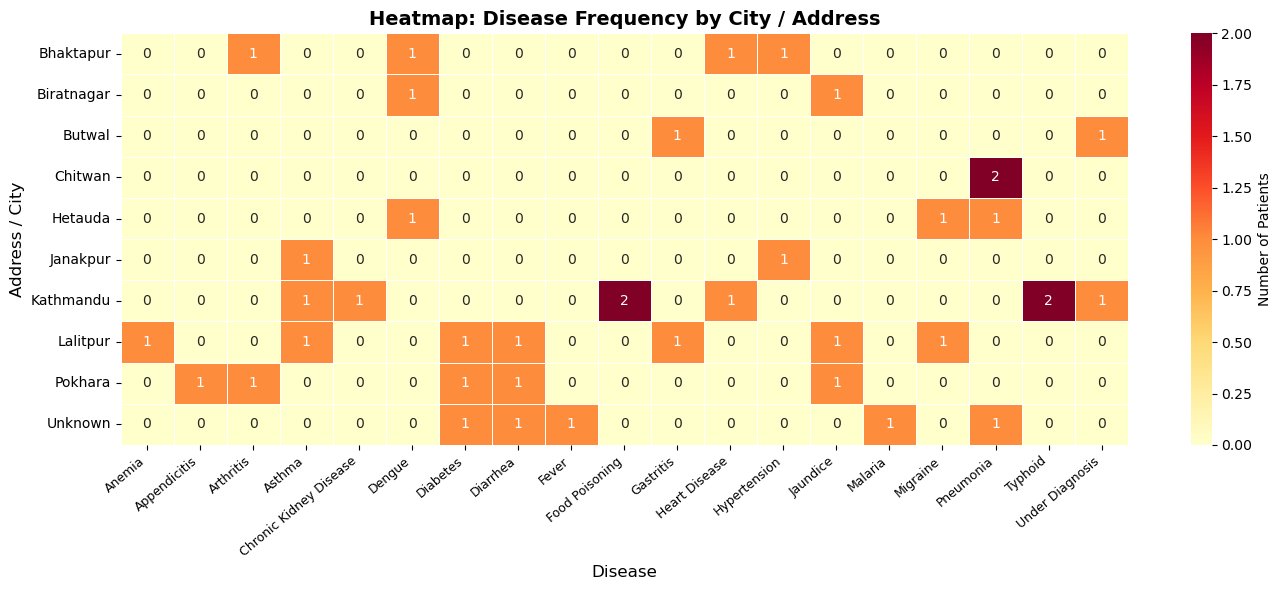

Plot 3 saved: plot3_disease_address_heatmap.png


In [12]:
# ============================================================
# PLOT 3 - Heatmap: Disease vs Address (patient count)
# ============================================================
import seaborn as sns
heat = df.groupby(['Address','Disease']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat,
            annot=True, fmt='d',
            cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Number of Patients'},
            ax=ax)
ax.set_xlabel('Disease', fontsize=12)
ax.set_ylabel('Address / City', fontsize=12)
ax.set_title('Heatmap: Disease Frequency by City / Address', fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
# plt.savefig('plot3_disease_address_heatmap.png', dpi=150)
plt.show()
print('Plot 3 saved: plot3_disease_address_heatmap.png')